# Interpretabilidad del Modelo : Random Forest (2018-2024)

Este notebook genera las visualizaciones de interpretabilidad del modelo
Random Forest seleccionado, incluyendo SHAP values y árbol de decisión individual.
Estas visualizaciones documentan cómo el modelo toma sus decisiones predictivas.


In [1]:
# -- Importaciones ----------------------------------------------
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz, plot_tree
import warnings

warnings.filterwarnings('ignore')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


## 1. Carga del modelo y datos

In [2]:
# -- Carga del modelo y datos ----------------------------------------------
rf = joblib.load('../data/models/random_forest.pkl')

test = pd.read_parquet('../data/clean/test.parquet')

FEATURES = ['tipo_eve','tipo_veh','g_hora_5','dia_sem_ocu',
            'sexo_per','edad_quinquenales','mayor_menor','depto_ocu']
TARGET = 'fall_les'

X_test = test[FEATURES]
y_test = test[TARGET]

print(f'✓ Modelo cargado — {rf.n_estimators} árboles')
print(f'✓ Test set: {X_test.shape[0]:,} registros × {X_test.shape[1]} features')

✓ Modelo cargado — 200 árboles
✓ Test set: 14,389 registros × 8 features


## 2. Árbol de decisión individual

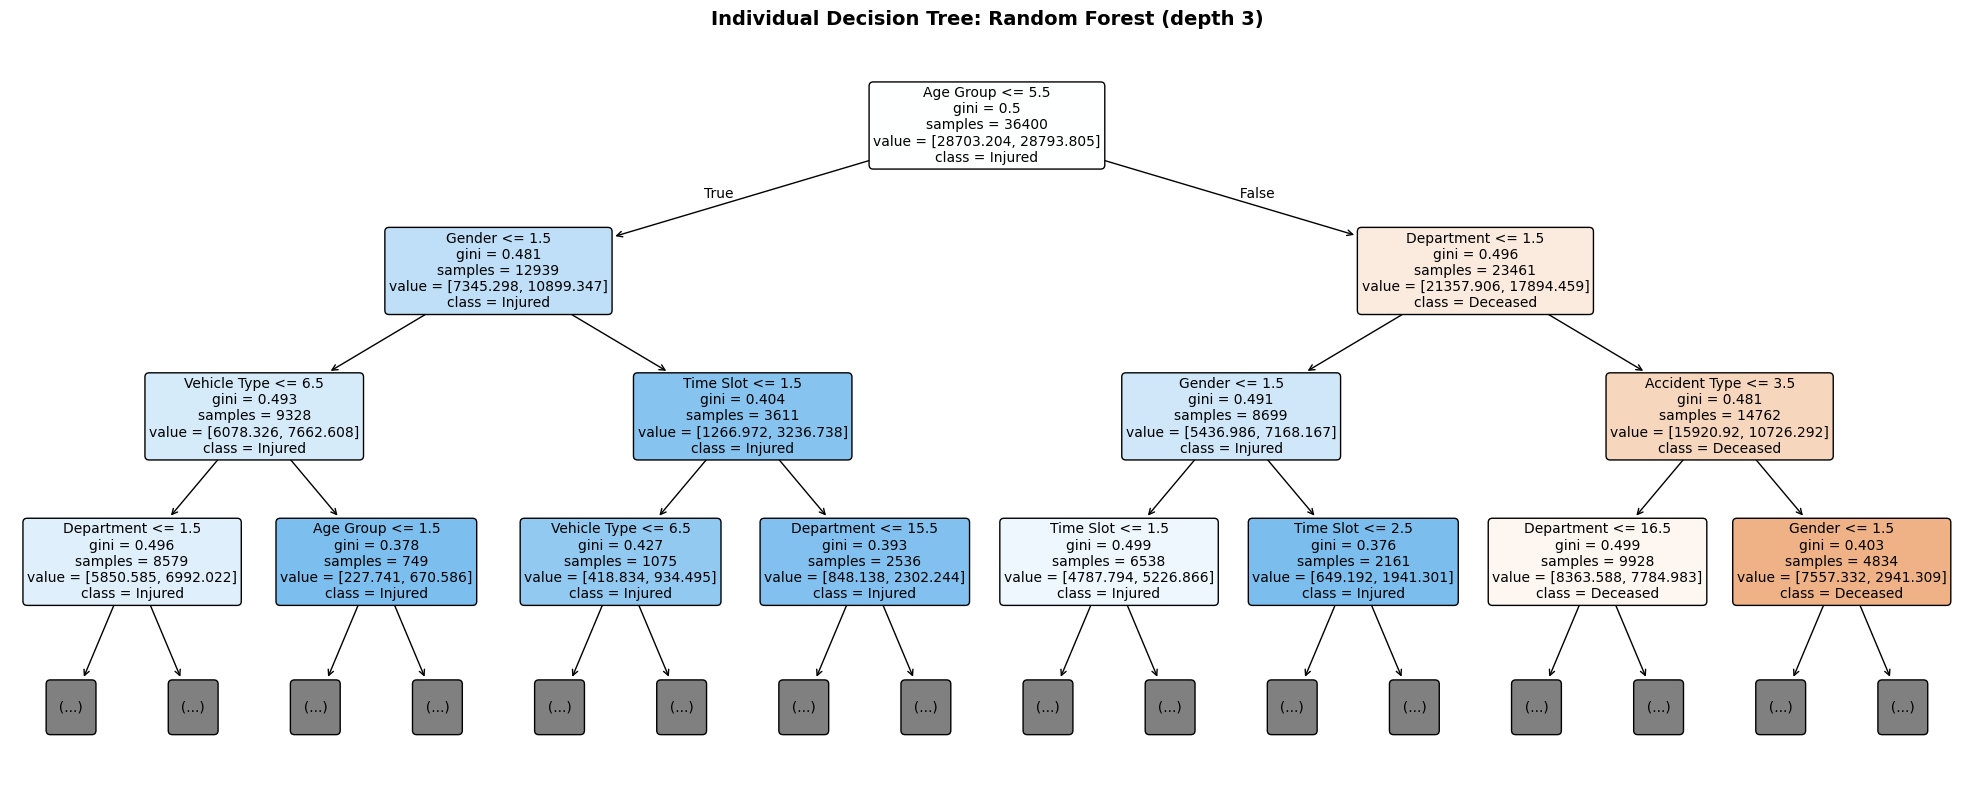

✓ Árbol guardado en data/models/arbol_decision.png


In [3]:
LABELS = {
    'tipo_eve': 'Accident Type',
    'tipo_veh': 'Vehicle Type',
    'g_hora_5': 'Time Slot',
    'dia_sem_ocu': 'Day of the Week',
    'sexo_per': 'Gender',
    'edad_quinquenales': 'Age Group',
    'mayor_menor': 'Age Status (Minor/Adult)',
    'depto_ocu': 'Department'
}

fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    rf.estimators_[0],
    feature_names=[LABELS[f] for f in FEATURES],
    class_names=['Deceased', 'Injured'],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
    fontsize=10
)

ax.set_title('Individual Decision Tree: Random Forest (depth 3)',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../data/models/arbol_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Árbol guardado en data/models/arbol_decision.png')

### Interpretación del árbol de decisión

Interpretación del árbol de decisión

La figura muestra uno de los árboles que conforman el Random Forest. Cada nodo representa una regla de decisión basada en las variables de entrada y evidencia cómo el modelo divide progresivamente los registros hasta alcanzar una predicción. Debido a que el Random Forest está compuesto por 200 árboles, esta visualización tiene un propósito ilustrativo y no representa por sí sola el comportamiento global del modelo.

## 3. SHAP Values : Interpretabilidad global

In [4]:
# -- Calcular SHAP  ----------------------------------------------
X_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

print(f'✓ SHAP values calculados')
print(f'  Shape: {shap_values.shape}')
print(f'  Tipo: {type(shap_values)}')

✓ SHAP values calculados
  Shape: (500, 8, 2)
  Tipo: <class 'shap._explanation.Explanation'>


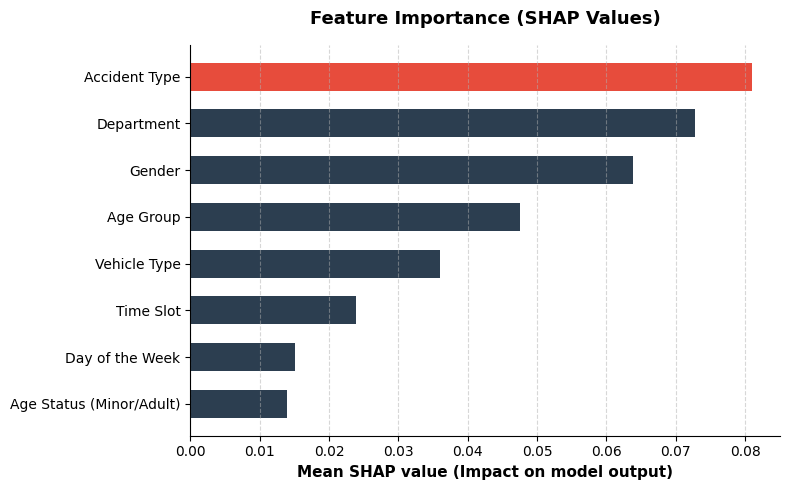

In [5]:
feature_names = [LABELS[f] for f in FEATURES] 

# 2. Calculamos los valores SHAP promedio
shap_values_mean = np.abs(shap_values.values[:, :, 0]).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP': shap_values_mean
}).sort_values('SHAP', ascending=True)


fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2c3e50' if x < shap_df['SHAP'].max() else '#e74c3c' for x in shap_df['SHAP']]

bars = ax.barh(shap_df['Feature'], shap_df['SHAP'], 
               color=colors, edgecolor='none', height=0.6)

ax.set_xlabel('Mean SHAP value (Impact on model output)', fontsize=11, fontweight='bold')
ax.set_title('Feature Importance (SHAP Values)', fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../data/models/shap_summary_ieee.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación SHAP: Importancia global

El análisis mediante valores SHAP muestra que **Tipo de evento** es la variable con mayor contribución promedio a las predicciones del modelo, seguida por **Departamento** y **Sexo**. Estas variables presentan una mayor influencia sobre la decisión del clasificador que el resto de los predictores considerados.

Este resultado es consistente con el objetivo del modelo, ya que las características propias del accidente aportan una mayor capacidad explicativa de la severidad del hecho que las variables demográficas analizadas de forma individual.

Por su parte, **Tipo de vehículo**, **Grupo de edad**, **Día de la semana**, **Grupo horario** y **Mayor/Menor de edad** también contribuyen a la predicción, aunque con una influencia relativa menor.

## 4. SHAP Beeswarm Plot : Impacto por valor de feature

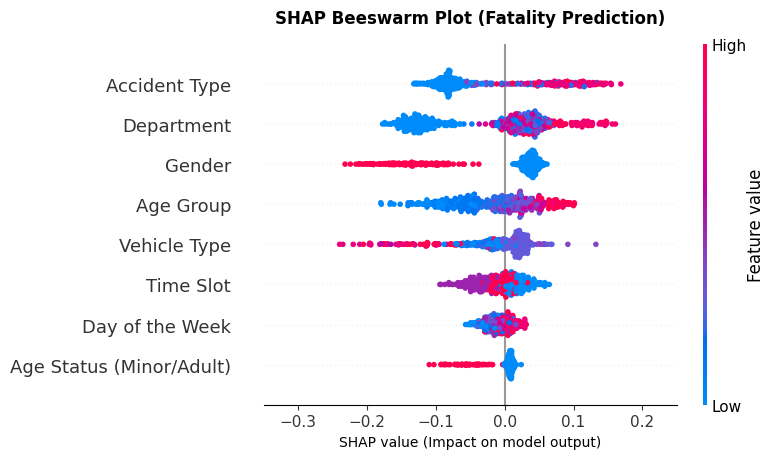

✓ Beeswarm plot saved for the paper


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

shap_class0 = shap.Explanation(
    values=shap_values.values[:, :, 0],
    base_values=shap_values.base_values[:, 0],
    data=X_sample.values,
    feature_names=[LABELS[f] for f in FEATURES] 
)

shap.plots.beeswarm(
    shap_class0,
    show=False,
    max_display=8
)

plt.title('SHAP Beeswarm Plot (Fatality Prediction)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('SHAP value (Impact on model output)', fontsize=10)


plt.xlim(-0.35, 0.25)


plt.tight_layout()
plt.savefig('../data/models/shap_beeswarm_ieee.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Beeswarm plot saved for the paper')

### Interpretación SHAP Beeswarm

El gráfico Beeswarm muestra la distribución del impacto de cada variable sobre las predicciones individuales del modelo.

- Los valores SHAP positivos incrementan la probabilidad de clasificar un registro como **Fallecido**.
- Los valores SHAP negativos favorecen la clasificación como **Lesionado**.
- El color representa el valor relativo que toma cada variable en cada observación.

#### Hallazgos principales

- **Tipo de evento** presenta la mayor influencia sobre las predicciones del modelo.
- **Departamento** y **Sexo** también muestran una contribución importante en la clasificación.
- **Tipo de vehículo**, **Grupo de edad** y las demás variables complementan la decisión del modelo, aunque con una influencia relativamente menor.

## 5. SHAP Waterfall : Explicación de predicción individual

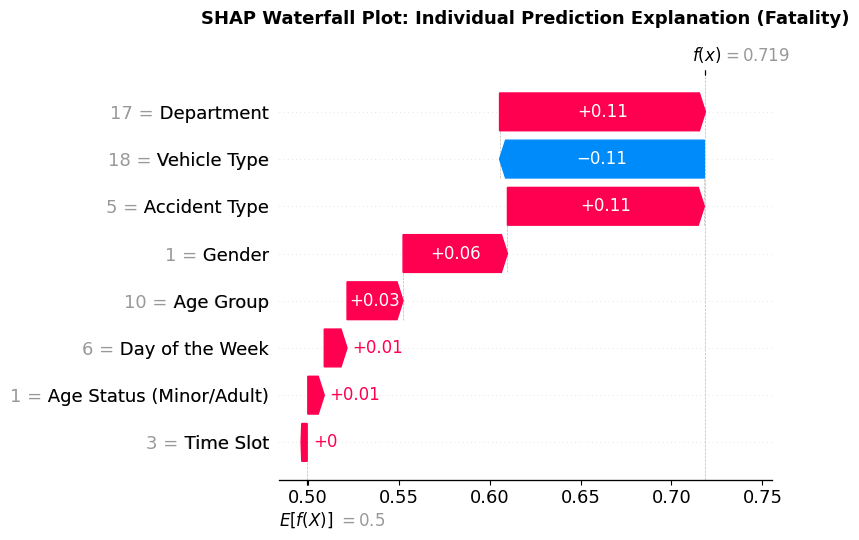

✓ Waterfall guardado


In [7]:
# -- SHAP Waterfall — caso individual ----------------------------------------------
idx_fallecido = X_sample[y_test.loc[X_sample.index] == 1].index[0]
pos = X_sample.index.get_loc(idx_fallecido)

shap.plots.waterfall(
    shap_class0[pos],
    show=False,
    max_display=8
)

plt.title('SHAP Waterfall Plot: Individual Prediction Explanation (Fatality)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../data/models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Waterfall guardado')

### Interpretación SHAP Waterfall

El gráfico Waterfall explica cómo cada variable contribuye a la predicción de un caso individual. Cada característica incrementa o disminuye la probabilidad estimada por el modelo hasta obtener la clasificación final.

Los valores SHAP positivos aumentan la probabilidad de la clase **Fallecido**, mientras que los valores negativos favorecen la clase **Lesionado**.

Esta representación permite interpretar de forma transparente el proceso de decisión del modelo para una observación específica, facilitando la comprensión de los factores que influyeron en la predicción realizada.

- Probabilidad base del modelo: **0.50**
- Department 17 (Petén) increases risk by +0.11
- Event Type 5 (Pedestrian Strike) increases risk by +0.11
- Vehicle Type 18 (Bicycle) decreases risk by -0.11
- Probabilidad final: **71.9%** de Fallecido

Esta explicación individual permite auditar cada predicción del modelo,
garantizando transparencia en la toma de decisiones.